In [1]:
#N1:imports + loaded raw EMNIST balanced binary files

import struct
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from itertools import cycle
import time
import matplotlib.pyplot as plt

BASE = '/kaggle/input/datasets/mtalhasohail/emnist-balanced-dataset'

with open(f'{BASE}/emnist-balanced-train-images-idx3-ubyte', 'rb') as f:
    magic, n, rows, cols = struct.unpack('>IIII', f.read(16))
    x_train_all = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows*cols)

with open(f'{BASE}/emnist-balanced-test-images-idx3-ubyte', 'rb') as f:
    magic, n, rows, cols = struct.unpack('>IIII', f.read(16))
    x_test_all = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows*cols)

with open(f'{BASE}/emnist-balanced-train-labels-idx1-ubyte', 'rb') as f:
    magic, n = struct.unpack('>II', f.read(8))
    y_train_all = np.frombuffer(f.read(), dtype=np.uint8)

with open(f'{BASE}/emnist-balanced-test-labels-idx1-ubyte', 'rb') as f:
    magic, n = struct.unpack('>II', f.read(8))
    y_test_all = np.frombuffer(f.read(), dtype=np.uint8)

print(f"train: {x_train_all.shape}   test: {x_test_all.shape}")
print(f"labels: {y_train_all.min()} to {y_train_all.max()}")



train: (112800, 784)   test: (18800, 784)
labels: 0 to 46


In [2]:
#N2: fixed EMNIST rotation

print("*** original ***")
for row in x_train_all[2].reshape(28, 28):
    print(''.join('#' if p > 100 else ' ' for p in row))
print("label:", y_train_all[2])

imgs = x_train_all.reshape(-1, 28, 28)
imgs = np.rot90(imgs, k=3, axes=(1, 2))
imgs = np.flip(imgs, axis=2)
x_train_all = imgs.reshape(-1, 784).copy()

imgs = x_test_all.reshape(-1, 28, 28)
imgs = np.rot90(imgs, k=3, axes=(1, 2))
imgs = np.flip(imgs, axis=2)
x_test_all = imgs.reshape(-1, 784).copy()

print("*** after fix ***")
for row in x_train_all[2].reshape(28, 28):
    print(''.join('#' if p > 100 else ' ' for p in row))
print("label:", y_train_all[2])


*** original ***
                            
                            
                ## # ###    
       ##################   
    #####################   
   ####################     
   ####      ####           
    ###    ####             
          ####              
         ###                
        ###                 
        ###                 
       ###                  
       ###                  
       ###                  
       ###                  
        #####               
         #######            
          ########          
              ######        
                 ####       
                   ###      
                   ###      
                   ##       
                  ##        
                            
                            
                            
label: 43
*** after fix ***
                            
                            
                            
     ##                     
    ####                   

In [3]:
#N3:defining 6 problems

SCRIPT_NAMES = ["P1_A-G", "P2_H-N", "P3_O-U", "P4_V-b", "P5_d-q", "P6_1-7"]

GROUP_LABELS = [
    [10, 11, 12, 13, 14, 15, 16],   # A B C D E F G
    [17, 18, 19, 20, 21, 22, 23],   # H I J K L M N
    [24, 25, 26, 27, 28, 29, 30],   # O P Q R S T U
    [31, 32, 33, 34, 35, 36, 37],   # V W X Y Z a b
    [38, 39, 40, 41, 42, 43, 44],   # d e f g h n q
    [1,  2,  3,  4,  5,  6,  7],    # 1 2 3 4 5 6 7
]
print("6 problems defined, 7 classes each, 42 classes total")



6 problems defined, 7 classes each, 42 classes total


In [4]:
#N4: building 6 datasets


train_datasets = []
test_datasets  = []

for m in range(6):
    labels   = GROUP_LABELS[m]
    mask     = np.isin(y_train_all, labels)
    x_tr     = x_train_all[mask].copy()
    y_tr_raw = y_train_all[mask].copy()
    y_tr     = np.zeros(len(y_tr_raw), dtype=np.int64)
    for new_label, old_label in enumerate(labels):
        y_tr[y_tr_raw == old_label] = new_label

    mask     = np.isin(y_test_all, labels)
    x_te     = x_test_all[mask].copy()
    y_te_raw = y_test_all[mask].copy()
    y_te     = np.zeros(len(y_te_raw), dtype=np.int64)
    for new_label, old_label in enumerate(labels):
        y_te[y_te_raw == old_label] = new_label

    x_tr = torch.tensor(x_tr, dtype=torch.float32)
    x_te = torch.tensor(x_te, dtype=torch.float32)
    y_tr = torch.tensor(y_tr, dtype=torch.long)
    y_te = torch.tensor(y_te, dtype=torch.long)

    mean, std = x_tr.mean(), x_tr.std()
    x_tr = (x_tr - mean) / std
    x_te = (x_te - mean) / std

    train_datasets.append(TensorDataset(x_tr, y_tr))
    test_datasets.append(TensorDataset(x_te, y_te))
    print(f"{SCRIPT_NAMES[m]}: train {len(x_tr):5d}  test {len(x_te):4d}  "
          f"mean {x_tr.mean():.2f}  std {x_tr.std():.2f}")


P1_A-G: train 16800  test 2800  mean -0.00  std 1.00
P2_H-N: train 16800  test 2800  mean -0.00  std 1.00
P3_O-U: train 16800  test 2800  mean 0.00  std 1.00
P4_V-b: train 16800  test 2800  mean 0.00  std 1.00
P5_d-q: train 16800  test 2800  mean 0.00  std 1.00
P6_1-7: train 16800  test 2800  mean -0.00  std 1.00


In [5]:
#N5:DataLoaders + settings

BATCH_SIZE = 32
train_loaders = [DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True) for ds in train_datasets]
test_loaders  = [DataLoader(ds, batch_size=256, shuffle=False)       for ds in test_datasets]

DEVICE          = 'cuda' if torch.cuda.is_available() else 'cpu'
INPUT_SIZE      = 784
HIDDEN_SIZE     = 128
NUM_G_SETS      = 4
NUM_PROBLEMS    = 6
CLASSES_PER     = 7
TOTAL_CLASSES   = NUM_PROBLEMS * CLASSES_PER   # 42

LEARNING_RATE   = 0.01
MOMENTUM        = 0.9
NUM_EPOCHS      = 20
STEPS_PER_EPOCH = 525
N_RUNS          = 30
EVAL_EVERY      = 5   
PRINT_EVERY     = 5

B_CONFIGS = torch.tensor([
    [1,1,0,0],
    [1,0,1,0],
    [1,0,0,1],
    [0,1,1,0],
    [0,1,0,1],
    [0,0,1,1],
], dtype=torch.float32).to(DEVICE)

#train loss = sum of 6 CE losses / 6   = average CE 
#test  loss = sum of 6 CE losses / 6   = average CE 

print(f"Device: {DEVICE}")
print(f"Runs: {N_RUNS}  Epochs: {NUM_EPOCHS}  Steps/epoch: {STEPS_PER_EPOCH}")
print(f"Both train loss and test loss = avg CE per problem")



Device: cuda
Runs: 30  Epochs: 20  Steps/epoch: 525
Both train loss and test loss = avg CE per problem


In [6]:
#N6: MODEL 1: WIDE 490-NEURON NETWORK
#Hidden layer: 490 neurons, 42 output neurons.
# 784*490 + 490*42 = 404,740 parameters
# Evaluation: 42-way argmax, no slicing

WIDE        = 490
accs_wide   = []
trloss_wide = []
teloss_wide = []

print(f"Training WIDE {WIDE}-NEURON network...")
print(f"{'Run':>4} {'Ep':>4} | {'Tr loss':>8} {'Te loss':>8} | "
      f"{'A-G':>6} {'H-N':>6} {'O-U':>6} {'V-b':>6} {'d-q':>6} {'1-7':>6}")
print("-" * 74)
t0 = time.time()

for run in range(N_RUNS):

    W_wide    = nn.Parameter(torch.empty(WIDE, INPUT_SIZE, device=DEVICE))
    Wout_wide = nn.Parameter(torch.empty(TOTAL_CLASSES, WIDE, device=DEVICE))
    nn.init.kaiming_normal_(W_wide.data,    mode="fan_in", nonlinearity="relu")
    nn.init.kaiming_normal_(Wout_wide.data, mode="fan_in", nonlinearity="relu")
    optimizer_wide = torch.optim.SGD([W_wide, Wout_wide], lr=LEARNING_RATE, momentum=MOMENTUM)
    inf_iters_wide = [cycle(loader) for loader in train_loaders]
    last_tr_loss   = 0.0

    for epoch in range(NUM_EPOCHS):

        # train
        epoch_loss = 0.0
        for step in range(STEPS_PER_EPOCH):
            optimizer_wide.zero_grad()
            total_loss = torch.zeros((), device=DEVICE)
            for m in range(6):
                x, y = next(inf_iters_wide[m])
                x, y = x.to(DEVICE), y.to(DEVICE)
                h   = F.relu(x @ W_wide.T)
                out = h @ Wout_wide.T              # [batch, 42]
                total_loss = total_loss + F.cross_entropy(out, y + m * CLASSES_PER)
            total_loss.backward()
            optimizer_wide.step()
            epoch_loss += total_loss.item()

        avg_tr       = epoch_loss / STEPS_PER_EPOCH / NUM_PROBLEMS
        last_tr_loss = avg_tr

        if (epoch + 1) % EVAL_EVERY == 0:
            ep_accs    = []
            ep_te_loss = 0.0
            with torch.no_grad():
                for m in range(6):
                    correct = total = 0
                    m_loss  = n_bat = 0.0
                    for x, y in test_loaders[m]:
                        x, y    = x.to(DEVICE), y.to(DEVICE)
                        h       = F.relu(x @ W_wide.T)
                        out     = h @ Wout_wide.T          # [batch, 42] — no slicing
                        pred    = out.argmax(1)             # 0..41
                        correct += (pred == y + m * CLASSES_PER).sum().item()
                        total   += y.size(0)
                        m_loss  += F.cross_entropy(out, y + m * CLASSES_PER).item()
                        n_bat   += 1
                    ep_accs.append(correct / total * 100)
                    ep_te_loss += m_loss / n_bat
            avg_te = ep_te_loss / NUM_PROBLEMS

            if (run + 1) % PRINT_EVERY == 0:
                acc_str = " ".join(f"{a:6.1f}" for a in ep_accs)
                print(f"{run+1:4d} {epoch+1:4d} | {avg_tr:8.4f} {avg_te:8.4f} | {acc_str}")

    # final eval
    run_accs    = []
    run_te_loss = 0.0
    with torch.no_grad():
        for m in range(6):
            correct = total = 0
            m_loss  = n_bat = 0.0
            for x, y in test_loaders[m]:
                x, y    = x.to(DEVICE), y.to(DEVICE)
                h       = F.relu(x @ W_wide.T)
                out     = h @ Wout_wide.T
                pred    = out.argmax(1)
                correct += (pred == y + m * CLASSES_PER).sum().item()
                total   += y.size(0)
                m_loss  += F.cross_entropy(out, y + m * CLASSES_PER).item()
                n_bat   += 1
            run_accs.append(correct / total * 100)
            run_te_loss += m_loss / n_bat

    accs_wide.append(run_accs)
    trloss_wide.append(last_tr_loss)
    teloss_wide.append(run_te_loss / NUM_PROBLEMS)

    if (run + 1) % PRINT_EVERY == 0:
        print(f"  → run {run+1} mean acc {np.mean(run_accs):.2f}%  "
              f"te loss {run_te_loss/NUM_PROBLEMS:.4f}  [{time.time()-t0:.0f}s]\n")

print(f"\nWIDE {WIDE} DONE:  acc {np.mean([np.mean(r) for r in accs_wide]):.2f}% ± "
      f"{np.std([np.mean(r) for r in accs_wide]):.2f}%  |  "
      f"train loss {np.mean(trloss_wide):.4f}  test loss {np.mean(teloss_wide):.4f}\n")

Training WIDE 490-NEURON network...
 Run   Ep |  Tr loss  Te loss |    A-G    H-N    O-U    V-b    d-q    1-7
--------------------------------------------------------------------------
   5    5 |   0.2641   0.5277 |   85.2   81.8   90.5   87.4   78.9   87.6
   5   10 |   0.1629   0.6231 |   86.9   83.6   88.5   88.2   77.8   89.2
   5   15 |   0.1266   0.6910 |   87.0   82.3   91.6   88.1   82.3   87.4
   5   20 |   0.1033   0.7654 |   88.4   83.8   92.4   88.3   80.1   86.9
  → run 5 mean acc 86.65%  te loss 0.7654  [181s]

  10    5 |   0.2674   0.5207 |   87.5   83.5   92.3   88.7   80.2   78.4
  10   10 |   0.1591   0.5952 |   87.8   81.5   91.8   88.9   82.0   83.5
  10   15 |   0.1200   0.7018 |   84.8   81.6   90.1   89.4   82.9   89.0
  10   20 |   0.0974   0.7591 |   89.5   82.3   91.2   90.4   80.5   87.0
  → run 10 mean acc 86.82%  te loss 0.7591  [357s]

  15    5 |   0.2646   0.4886 |   85.8   82.5   90.6   88.6   82.8   85.8
  15   10 |   0.1576   0.5892 |   87.0   82.9 

In [7]:

#N7: MODEL 2: SIX INDEPENDENT NETWORKS
# Each problem has its own hidden + output weights.
# 101,248 parameters each, 607,488 total

accs_six    = []
trloss_six  = []
teloss_six  = []

print("Training 6 INDEPENDENT networks...")
print(f"{'Run':>4} {'Ep':>4} | {'Tr loss':>8} {'Te loss':>8} | "
      f"{'A-G':>6} {'H-N':>6} {'O-U':>6} {'V-b':>6} {'d-q':>6} {'1-7':>6}")
print("-" * 74)
t0 = time.time()

for run in range(N_RUNS):

    W_six    = []
    Wout_six = []
    opts_six = []
    for m in range(6):
        w_h = nn.Parameter(torch.empty(HIDDEN_SIZE, INPUT_SIZE, device=DEVICE))
        w_o = nn.Parameter(torch.empty(CLASSES_PER, HIDDEN_SIZE, device=DEVICE))
        nn.init.kaiming_normal_(w_h.data, mode="fan_in", nonlinearity="relu")
        nn.init.kaiming_normal_(w_o.data, mode="fan_in", nonlinearity="relu")
        W_six.append(w_h)
        Wout_six.append(w_o)
        opts_six.append(torch.optim.SGD([w_h, w_o], lr=LEARNING_RATE, momentum=MOMENTUM))

    inf_iters_six = [cycle(loader) for loader in train_loaders]
    last_tr_loss  = 0.0

    for epoch in range(NUM_EPOCHS):
        epoch_loss = 0.0
        for m in range(6):
            for step in range(STEPS_PER_EPOCH):
                opts_six[m].zero_grad()
                x, y = next(inf_iters_six[m])
                x, y = x.to(DEVICE), y.to(DEVICE)
                out  = F.relu(x @ W_six[m].T) @ Wout_six[m].T
                loss = F.cross_entropy(out, y)
                loss.backward()
                opts_six[m].step()
                epoch_loss += loss.item()

        #avg train loss
        avg_tr       = epoch_loss / NUM_PROBLEMS / STEPS_PER_EPOCH
        last_tr_loss = avg_tr

        if (epoch + 1) % EVAL_EVERY == 0:
            ep_accs    = []
            ep_te_loss = 0.0
            with torch.no_grad():
                for m in range(6):
                    correct = total = 0
                    m_loss  = n_bat = 0.0
                    for x, y in test_loaders[m]:
                        x, y    = x.to(DEVICE), y.to(DEVICE)
                        out     = F.relu(x @ W_six[m].T) @ Wout_six[m].T
                        correct += (out.argmax(1) == y).sum().item()
                        total   += y.size(0)
                        m_loss  += F.cross_entropy(out, y).item()
                        n_bat   += 1
                    ep_accs.append(correct / total * 100)
                    ep_te_loss += m_loss / n_bat
            avg_te = ep_te_loss / NUM_PROBLEMS #avg test loss

            if (run + 1) % PRINT_EVERY == 0:
                acc_str = " ".join(f"{a:6.1f}" for a in ep_accs)
                print(f"{run+1:4d} {epoch+1:4d} | {avg_tr:8.4f} {avg_te:8.4f} | {acc_str}")

    run_accs    = []
    run_te_loss = 0.0
    with torch.no_grad():
        for m in range(6):
            correct = total = 0
            m_loss  = n_bat = 0.0
            for x, y in test_loaders[m]:
                x, y    = x.to(DEVICE), y.to(DEVICE)
                out     = F.relu(x @ W_six[m].T) @ Wout_six[m].T
                correct += (out.argmax(1) == y).sum().item()
                total   += y.size(0)
                m_loss  += F.cross_entropy(out, y).item()
                n_bat   += 1
            run_accs.append(correct / total * 100)
            run_te_loss += m_loss / n_bat

    accs_six.append(run_accs)
    trloss_six.append(last_tr_loss)
    teloss_six.append(run_te_loss / NUM_PROBLEMS)

    if (run + 1) % PRINT_EVERY == 0:
        print(f"  → run {run+1} mean acc {np.mean(run_accs):.2f}%  "
              f"te loss {run_te_loss/NUM_PROBLEMS:.4f}  [{time.time()-t0:.0f}s]\n")

print(f"\n6 INDEPENDENT DONE:  "
      f"acc {np.mean([np.mean(r) for r in accs_six]):.2f}% ± "
      f"{np.std([np.mean(r) for r in accs_six]):.2f}%  |  "
      f"train loss {np.mean(trloss_six):.4f}  test loss {np.mean(teloss_six):.4f}\n")


Training 6 INDEPENDENT networks...
 Run   Ep |  Tr loss  Te loss |    A-G    H-N    O-U    V-b    d-q    1-7
--------------------------------------------------------------------------
   5    5 |   0.0736   0.1757 |   96.3   88.9   97.0   95.8   89.8   98.1
   5   10 |   0.0396   0.1885 |   96.9   88.9   97.4   96.3   89.5   98.4
   5   15 |   0.0298   0.2067 |   96.8   89.3   97.2   96.2   89.0   98.5
   5   20 |   0.0252   0.2210 |   96.8   89.2   97.2   96.1   89.3   98.5
  → run 5 mean acc 94.52%  te loss 0.2210  [294s]

  10    5 |   0.0745   0.1768 |   95.5   88.4   97.2   95.4   90.0   98.4
  10   10 |   0.0402   0.1871 |   96.5   89.8   97.1   96.3   90.2   98.4
  10   15 |   0.0299   0.2067 |   96.4   89.8   97.3   96.3   90.0   98.4
  10   20 |   0.0253   0.2242 |   96.5   89.3   97.4   96.2   90.0   98.5
  → run 10 mean acc 94.64%  te loss 0.2242  [590s]

  15    5 |   0.0760   0.1794 |   95.5   88.9   97.1   95.3   89.6   98.4
  15   10 |   0.0409   0.1844 |   96.5   89.5  

In [8]:
#N8: MODEL 3: b=[1,0,0,0]
#Used G1 only & 42 output neurons
# 784*128 + 128*42 = 105,728 parameters
# Evaluation: 42-way argmax, no slicing

accs_b1000    = []
trloss_b1000  = []
teloss_b1000  = []

print("Training b=[1,0,0,0]...")
print(f"{'Run':>4} {'Ep':>4} | {'Tr loss':>8} {'Te loss':>8} | "
      f"{'A-G':>6} {'H-N':>6} {'O-U':>6} {'V-b':>6} {'d-q':>6} {'1-7':>6}")
print("-" * 74)
t0 = time.time()

for run in range(N_RUNS):

    Ghid_b1000 = nn.Parameter(torch.empty(4, HIDDEN_SIZE, INPUT_SIZE, device=DEVICE))
    for n in range(4):
        nn.init.kaiming_normal_(Ghid_b1000.data[n], mode="fan_in", nonlinearity="relu")

    Wout_b1000 = nn.Parameter(torch.empty(TOTAL_CLASSES, HIDDEN_SIZE, device=DEVICE))
    nn.init.kaiming_normal_(Wout_b1000.data, mode="fan_in", nonlinearity="relu")

    b_fixed         = torch.tensor([1,0,0,0], dtype=torch.float32, device=DEVICE)
    optimizer_b1000 = torch.optim.SGD([Ghid_b1000, Wout_b1000], lr=LEARNING_RATE, momentum=MOMENTUM)
    inf_iters_b1000 = [cycle(loader) for loader in train_loaders]
    last_tr_loss    = 0.0

    for epoch in range(NUM_EPOCHS):

        # train
        epoch_loss = 0.0
        for step in range(STEPS_PER_EPOCH):
            optimizer_b1000.zero_grad()
            total_loss = torch.zeros((), device=DEVICE)
            for m in range(6):
                x, y = next(inf_iters_b1000[m])
                x, y = x.to(DEVICE), y.to(DEVICE)
                W    = torch.einsum('n,nhi->hi', b_fixed, Ghid_b1000)
                h    = F.relu(x @ W.T)
                out  = h @ Wout_b1000.T              # [batch, 42]
                total_loss = total_loss + F.cross_entropy(out, y + m * CLASSES_PER)
            total_loss.backward()
            optimizer_b1000.step()
            epoch_loss += total_loss.item()

        avg_tr       = epoch_loss / STEPS_PER_EPOCH / NUM_PROBLEMS
        last_tr_loss = avg_tr

        if (epoch + 1) % EVAL_EVERY == 0:
            ep_accs    = []
            ep_te_loss = 0.0
            with torch.no_grad():
                W = torch.einsum('n,nhi->hi', b_fixed, Ghid_b1000)
                for m in range(6):
                    correct = total = 0
                    m_loss  = n_bat = 0.0
                    for x, y in test_loaders[m]:
                        x, y    = x.to(DEVICE), y.to(DEVICE)
                        out     = F.relu(x @ W.T) @ Wout_b1000.T  # [batch, 42] — no slicing
                        pred    = out.argmax(1)                     # 0..41
                        correct += (pred == y + m * CLASSES_PER).sum().item()
                        total   += y.size(0)
                        m_loss  += F.cross_entropy(out, y + m * CLASSES_PER).item()
                        n_bat   += 1
                    ep_accs.append(correct / total * 100)
                    ep_te_loss += m_loss / n_bat
            avg_te = ep_te_loss / NUM_PROBLEMS

            if (run + 1) % PRINT_EVERY == 0:
                acc_str = " ".join(f"{a:6.1f}" for a in ep_accs)
                print(f"{run+1:4d} {epoch+1:4d} | {avg_tr:8.4f} {avg_te:8.4f} | {acc_str}")

    # final eval
    run_accs    = []
    run_te_loss = 0.0
    with torch.no_grad():
        W = torch.einsum('n,nhi->hi', b_fixed, Ghid_b1000)
        for m in range(6):
            correct = total = 0
            m_loss  = n_bat = 0.0
            for x, y in test_loaders[m]:
                x, y    = x.to(DEVICE), y.to(DEVICE)
                out     = F.relu(x @ W.T) @ Wout_b1000.T
                pred    = out.argmax(1)
                correct += (pred == y + m * CLASSES_PER).sum().item()
                total   += y.size(0)
                m_loss  += F.cross_entropy(out, y + m * CLASSES_PER).item()
                n_bat   += 1
            run_accs.append(correct / total * 100)
            run_te_loss += m_loss / n_bat

    accs_b1000.append(run_accs)
    trloss_b1000.append(last_tr_loss)
    teloss_b1000.append(run_te_loss / NUM_PROBLEMS)

    if (run + 1) % PRINT_EVERY == 0:
        print(f"  → run {run+1} mean acc {np.mean(run_accs):.2f}%  "
              f"te loss {run_te_loss/NUM_PROBLEMS:.4f}  [{time.time()-t0:.0f}s]\n")

print(f"\nb=1000 DONE:  acc {np.mean([np.mean(r) for r in accs_b1000]):.2f}% ± "
      f"{np.std([np.mean(r) for r in accs_b1000]):.2f}%  |  "
      f"train loss {np.mean(trloss_b1000):.4f}  test loss {np.mean(teloss_b1000):.4f}\n")

Training b=[1,0,0,0]...
 Run   Ep |  Tr loss  Te loss |    A-G    H-N    O-U    V-b    d-q    1-7
--------------------------------------------------------------------------
   5    5 |   0.4522   0.6057 |   86.4   79.2   85.0   87.3   75.0   82.6
   5   10 |   0.3778   0.6555 |   87.5   79.0   85.2   87.1   74.9   84.0
   5   15 |   0.3341   0.7131 |   85.5   78.6   87.1   85.8   75.5   85.0
   5   20 |   0.3106   0.7946 |   85.0   77.8   86.9   85.4   77.0   84.8
  → run 5 mean acc 82.81%  te loss 0.7946  [233s]

  10    5 |   0.4406   0.6004 |   84.5   80.7   87.5   84.5   76.9   80.9
  10   10 |   0.3666   0.6552 |   85.2   81.0   88.4   85.5   75.0   83.1
  10   15 |   0.3284   0.7390 |   85.8   79.5   87.5   86.4   74.1   81.4
  10   20 |   0.3017   0.8075 |   85.7   80.2   87.3   85.5   74.9   82.2
  → run 10 mean acc 82.63%  te loss 0.8075  [465s]

  15    5 |   0.4471   0.5819 |   84.8   78.5   88.1   88.2   76.5   83.1
  15   10 |   0.3697   0.6415 |   86.2   81.6   87.5   87.

In [9]:
#N9: MODEL 4: COMPOUND SYNAPSE
# 4 G sets hidden + 4 G sets output. Same b picks 2-of-4 in both.
# 4 * [784*128 + 128*7] = 404,992 parameters

accs_compound    = []
trloss_compound  = []
teloss_compound  = []

print("Training COMPOUND SYNAPSE...")
print(f"{'Run':>4} {'Ep':>4} | {'Tr loss':>8} {'Te loss':>8} | "
      f"{'A-G':>6} {'H-N':>6} {'O-U':>6} {'V-b':>6} {'d-q':>6} {'1-7':>6}")
print("-" * 74)
t0 = time.time()

for run in range(N_RUNS):

    Ghid_comp = nn.Parameter(torch.empty(4, HIDDEN_SIZE, INPUT_SIZE, device=DEVICE))
    Gout_comp = nn.Parameter(torch.empty(4, CLASSES_PER, HIDDEN_SIZE, device=DEVICE))
    for n in range(4):
        nn.init.kaiming_normal_(Ghid_comp.data[n], mode="fan_in", nonlinearity="relu")
        nn.init.kaiming_normal_(Gout_comp.data[n], mode="fan_in", nonlinearity="relu")

    optimizer_comp = torch.optim.SGD([Ghid_comp, Gout_comp], lr=LEARNING_RATE, momentum=MOMENTUM)
    inf_iters_comp = [cycle(loader) for loader in train_loaders]
    last_tr_loss   = 0.0

    for epoch in range(NUM_EPOCHS):
        epoch_loss = 0.0
        for step in range(STEPS_PER_EPOCH):
            optimizer_comp.zero_grad()
            total_loss = torch.zeros((), device=DEVICE)
            for m in range(6):
                x, y = next(inf_iters_comp[m])
                x, y = x.to(DEVICE), y.to(DEVICE)
                b    = B_CONFIGS[m]
                W    = torch.einsum('n,nhi->hi', b, Ghid_comp)
                Wout = torch.einsum('n,noh->oh', b, Gout_comp)
                h    = F.relu(x @ W.T)
                out  = h @ Wout.T
                total_loss = total_loss + F.cross_entropy(out, y)
            total_loss.backward()
            optimizer_comp.step()
            epoch_loss += total_loss.item()

        avg_tr       = epoch_loss / STEPS_PER_EPOCH / NUM_PROBLEMS
        last_tr_loss = avg_tr

        if (epoch + 1) % EVAL_EVERY == 0:
            ep_accs    = []
            ep_te_loss = 0.0
            with torch.no_grad():
                for m in range(6):
                    correct = total = 0
                    m_loss  = n_bat = 0.0
                    b    = B_CONFIGS[m]
                    W    = torch.einsum('n,nhi->hi', b, Ghid_comp)
                    Wout = torch.einsum('n,noh->oh', b, Gout_comp)
                    for x, y in test_loaders[m]:
                        x, y    = x.to(DEVICE), y.to(DEVICE)
                        out     = F.relu(x @ W.T) @ Wout.T
                        correct += (out.argmax(1) == y).sum().item()
                        total   += y.size(0)
                        m_loss  += F.cross_entropy(out, y).item()
                        n_bat   += 1
                    ep_accs.append(correct / total * 100)
                    ep_te_loss += m_loss / n_bat
            avg_te = ep_te_loss / NUM_PROBLEMS

            if (run + 1) % PRINT_EVERY == 0:
                acc_str = " ".join(f"{a:6.1f}" for a in ep_accs)
                print(f"{run+1:4d} {epoch+1:4d} | {avg_tr:8.4f} {avg_te:8.4f} | {acc_str}")

    run_accs    = []
    run_te_loss = 0.0
    with torch.no_grad():
        for m in range(6):
            correct = total = 0
            m_loss  = n_bat = 0.0
            b    = B_CONFIGS[m]
            W    = torch.einsum('n,nhi->hi', b, Ghid_comp)
            Wout = torch.einsum('n,noh->oh', b, Gout_comp)
            for x, y in test_loaders[m]:
                x, y    = x.to(DEVICE), y.to(DEVICE)
                out     = F.relu(x @ W.T) @ Wout.T
                correct += (out.argmax(1) == y).sum().item()
                total   += y.size(0)
                m_loss  += F.cross_entropy(out, y).item()
                n_bat   += 1
            run_accs.append(correct / total * 100)
            run_te_loss += m_loss / n_bat

    accs_compound.append(run_accs)
    trloss_compound.append(last_tr_loss)
    teloss_compound.append(run_te_loss / NUM_PROBLEMS)

    if (run + 1) % PRINT_EVERY == 0:
        print(f"  → run {run+1} mean acc {np.mean(run_accs):.2f}%  "
              f"te loss {run_te_loss/NUM_PROBLEMS:.4f}  [{time.time()-t0:.0f}s]\n")

print(f"\nCOMPOUND DONE:  "
      f"acc {np.mean([np.mean(r) for r in accs_compound]):.2f}% ± "
      f"{np.std([np.mean(r) for r in accs_compound]):.2f}%  |  "
      f"train loss {np.mean(trloss_compound):.4f}  test loss {np.mean(teloss_compound):.4f}\n")



Training COMPOUND SYNAPSE...
 Run   Ep |  Tr loss  Te loss |    A-G    H-N    O-U    V-b    d-q    1-7
--------------------------------------------------------------------------
   5    5 |   0.0929   0.2459 |   94.4   88.1   96.9   94.7   87.5   97.6
   5   10 |   0.0608   0.2956 |   95.5   87.5   97.1   95.2   87.0   98.1
   5   15 |   0.0410   0.3170 |   95.3   88.5   97.1   95.2   87.5   98.2
   5   20 |   0.0351   0.3555 |   95.8   88.8   97.1   95.2   88.2   98.0
  → run 5 mean acc 93.87%  te loss 0.3555  [271s]

  10    5 |   0.0925   0.2262 |   95.5   87.9   96.4   95.2   88.9   97.8
  10   10 |   0.0565   0.2728 |   95.4   88.0   97.0   95.7   89.4   97.9
  10   15 |   0.0413   0.3111 |   95.5   88.8   96.6   95.5   89.7   98.0
  10   20 |   0.0353   0.3532 |   95.8   88.4   96.6   95.5   89.3   97.7
  → run 10 mean acc 93.88%  te loss 0.3532  [542s]

  15    5 |   0.0957   0.2385 |   94.0   86.9   96.2   94.6   89.0   98.1
  15   10 |   0.0538   0.2656 |   95.3   88.2   96.7 

Model                   Params    Mean acc     Std   Tr loss   Te loss
----------------------------------------------------------------------------
Wide 490               404,740      86.62%   0.30%    0.0981    0.7806
6 indep                607,488      94.57%   0.09%    0.0254    0.2240
b=1000                 105,728      82.66%   0.44%    0.3138    0.8084
Compound               404,992      93.86%   0.22%    0.0345    0.3465
  (train loss = test loss scale: avg CE per problem  |  random guess ≈ 1.945)

PER-PROBLEM TEST ACCURACY — mean over 30 runs
Problem          Wide490     6 indep      b=1000    Compound  Best
------------------------------------------------------------------------
P1_A-G            87.72%      96.53%      83.65%      95.64%  6 indep
P2_H-N            82.99%      89.17%      78.74%      88.53%  6 indep
P3_O-U            91.39%      97.39%      87.74%      96.70%  6 indep
P4_V-b            89.27%      96.33%      85.31%      95.50%  6 indep
P5_d-q            80.09

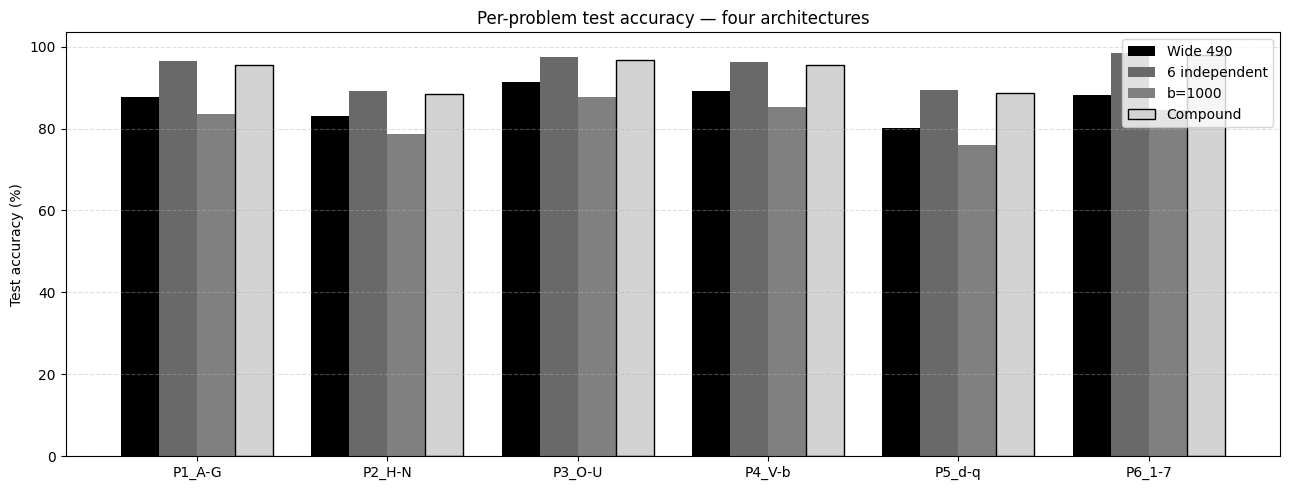

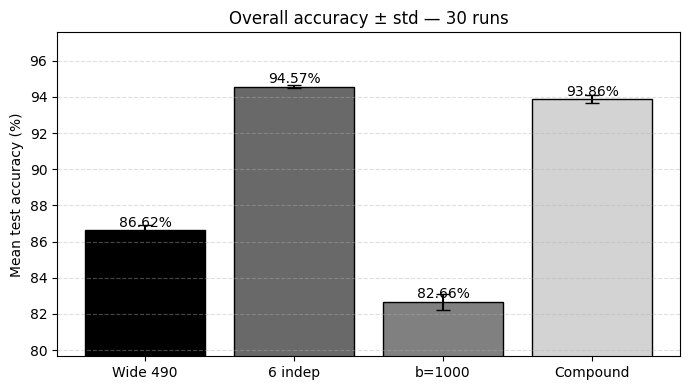

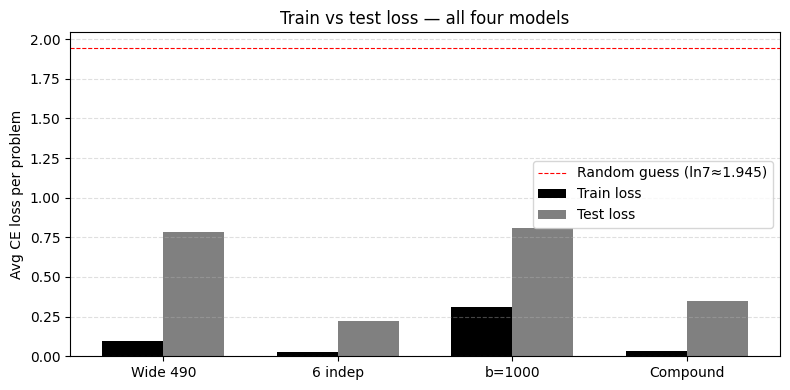

In [10]:
#N10: FINAL COMPARISON


mean_wide     = [np.mean([r[m] for r in accs_wide])     for m in range(6)]
mean_six      = [np.mean([r[m] for r in accs_six])      for m in range(6)]
mean_b1000    = [np.mean([r[m] for r in accs_b1000])    for m in range(6)]
mean_compound = [np.mean([r[m] for r in accs_compound]) for m in range(6)]

std_wide     = np.std([np.mean(r) for r in accs_wide])
std_six      = np.std([np.mean(r) for r in accs_six])
std_b1000    = np.std([np.mean(r) for r in accs_b1000])
std_compound = np.std([np.mean(r) for r in accs_compound])

# Table 1: overall accuracy + loss 
print("=" * 76)
print(f"{'Model':<20}{'Params':>10}{'Mean acc':>12}{'Std':>8}{'Tr loss':>10}{'Te loss':>10}")
print("-" * 76)
rows = [
    ("Wide 490",  "404,740", mean_wide,     std_wide,     trloss_wide,     teloss_wide),
    ("6 indep",   "607,488", mean_six,      std_six,      trloss_six,      teloss_six),
    ("b=1000",    "105,728", mean_b1000,    std_b1000,    trloss_b1000,    teloss_b1000),
    ("Compound",  "404,992", mean_compound, std_compound, trloss_compound, teloss_compound),
]
for name, params, means, std, trl, tel in rows:
    print(f"{name:<20}{params:>10}{np.mean(means):>11.2f}%{std:>7.2f}%"
          f"{np.mean(trl):>10.4f}{np.mean(tel):>10.4f}")
print("=" * 76)
print("  (train loss = test loss scale: avg CE per problem  |  random guess ≈ 1.945)")

#Table 2: per-problem accuracy
print(f"\nPER-PROBLEM TEST ACCURACY — mean over {N_RUNS} runs")
print("=" * 72)
print(f"{'Problem':<12}{'Wide490':>12}{'6 indep':>12}{'b=1000':>12}{'Compound':>12}  Best")
print("-" * 72)
models_list = ["Wide490", "6 indep", "b=1000", "Compound"]
for m in range(6):
    vals = [mean_wide[m], mean_six[m], mean_b1000[m], mean_compound[m]]
    best = models_list[int(np.argmax(vals))]
    print(f"{SCRIPT_NAMES[m]:<12}"
          f"{mean_wide[m]:>11.2f}%"
          f"{mean_six[m]:>11.2f}%"
          f"{mean_b1000[m]:>11.2f}%"
          f"{mean_compound[m]:>11.2f}%  {best}")
print("-" * 72)
print(f"{'MEAN':<12}"
      f"{np.mean(mean_wide):>11.2f}%"
      f"{np.mean(mean_six):>11.2f}%"
      f"{np.mean(mean_b1000):>11.2f}%"
      f"{np.mean(mean_compound):>11.2f}%")
print("=" * 72)

print(f"\n({N_RUNS} runs, {NUM_EPOCHS} epochs, {STEPS_PER_EPOCH} steps/epoch, "
      f"SGD lr={LEARNING_RATE} momentum={MOMENTUM})")

#Chart 1: per-problem grouped bar 
x = np.arange(6)
w = 0.2
plt.figure(figsize=(13, 5))
plt.bar(x-1.5*w, mean_wide,     w, label='Wide 490',     color='black')
plt.bar(x-0.5*w, mean_six,      w, label='6 independent',color='dimgray')
plt.bar(x+0.5*w, mean_b1000,    w, label='b=1000',       color='gray')
plt.bar(x+1.5*w, mean_compound, w, label='Compound',     color='lightgray', edgecolor='black')
plt.xticks(x, SCRIPT_NAMES)
plt.ylabel('Test accuracy (%)')
plt.title('Per-problem test accuracy — four architectures')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Chart 2: overall accuracy ± std
labels_bar = ['Wide 490', '6 indep', 'b=1000', 'Compound']
means_bar  = [np.mean(mean_wide), np.mean(mean_six),
              np.mean(mean_b1000), np.mean(mean_compound)]
stds_bar   = [std_wide, std_six, std_b1000, std_compound]
plt.figure(figsize=(7, 4))
bars = plt.bar(labels_bar, means_bar,
               color=['black','dimgray','gray','lightgray'],
               edgecolor='black', yerr=stds_bar, capsize=5)
for bar, val in zip(bars, means_bar):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{val:.2f}%', ha='center', fontsize=10)
plt.ylabel('Mean test accuracy (%)')
plt.title(f'Overall accuracy ± std — {N_RUNS} runs')
plt.ylim(min(means_bar)-3, max(means_bar)+3)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#Chart 3: train vs test loss per model
labels_bar  = ['Wide 490', '6 indep', 'b=1000', 'Compound']
tr_means    = [np.mean(trloss_wide), np.mean(trloss_six),
               np.mean(trloss_b1000), np.mean(trloss_compound)]
te_means    = [np.mean(teloss_wide), np.mean(teloss_six),
               np.mean(teloss_b1000), np.mean(teloss_compound)]
x2 = np.arange(4)
w2 = 0.35
plt.figure(figsize=(8, 4))
plt.bar(x2-w2/2, tr_means, w2, label='Train loss', color='black')
plt.bar(x2+w2/2, te_means, w2, label='Test loss',  color='gray')
plt.xticks(x2, labels_bar)
plt.ylabel('Avg CE loss per problem')
plt.title('Train vs test loss — all four models')
plt.axhline(y=1.945, color='red', linestyle='--', linewidth=0.8, label='Random guess (ln7≈1.945)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()